# JPSS VIIRS True Color

VIIRS is an orbital swath, not a fixed disk: every pixel carries its own
latitude and longitude in a separate geolocation file. Keep the band files and
their geolocation from the same pass in one folder -- `GMTCO` goes with the M
bands, `GITCO` with the I bands.

Unlike ABI, VIIRS has a real green band, so nothing is synthesised.

Everything is in this notebook: the folder your files are in, the box
you choose, and the whole plotting code. Change any of it and re-run.

Download the files first with the
[GOES & JPSS Data Downloader](https://rmsm95.github.io/GOES-NESDIS_downlaoder/);
nothing is downloaded here.

**Steps:** point at your folder -> plot the whole scan -> set your box -> plot
that box.

## Setup

In [1]:
import glob
import sys
from pathlib import Path

import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image, display
from shapely.geometry import box as shapely_box

sys.path.insert(0, "..")
import goestools as gt


In [2]:
# ---------------------------------------------------------------
# Settings come from config.yml at the repository root. Override any of them
# in the next few lines if you want a one-off change.
# ---------------------------------------------------------------
CONFIG = yaml.safe_load(open("../config.yml"))
style = CONFIG["style"]

COAST_COLOUR = style["coast_colour"]
COAST_WIDTH = style["coast_width"]
COAST_RES = style["coast_resolution"]

GRID_COLOUR = style["grid_colour"]
GRID_ALPHA = style["grid_alpha"]
GRID_STYLE = style["grid_style"]
GRID_WIDTH = style["grid_width"]

MARKER_LON = style["marker_lon"]          # None hides the marker
MARKER_LAT = style["marker_lat"]
MARKER_COLOUR = style["marker_colour"]
MARKER_SIZE = style["marker_size"]

FIG_WIDTH = style["figure_width"]
DPI = style["dpi"]
STRIDE = style["overview_stride"]         # every n-th pixel for the whole scan


In [3]:
# ---------------------------------------------------------------
# Kept here so you can change them: coastlines clipped to a box, and the
# degree labels on the axes.
# ---------------------------------------------------------------
def coastlines(west, east, south, north, resolution="10m"):
    clip = shapely_box(west, south, east, north)
    segments = []
    feature = cfeature.NaturalEarthFeature("physical", "coastline", resolution)
    for geometry in feature.intersecting_geometries([west, east, south, north]):
        piece = geometry.intersection(clip)
        for line in (piece.geoms if hasattr(piece, "geoms") else [piece]):
            if not line.is_empty and line.length > 0:
                x, y = line.xy
                segments.append((np.asarray(x), np.asarray(y)))
    return segments


def lon_label(value, _pos=None):
    v = ((value + 180) % 360) - 180
    return f"{abs(v):g}\u00b0{'E' if v >= 0 else 'W'}"


def lat_label(value, _pos=None):
    return f"{abs(value):g}\u00b0{'N' if value >= 0 else 'S'}"


def decorate(ax, west, east, south, north, left_title, when):
    """Coastlines, graticule, degree labels and the two-part header."""
    ax.grid(color=GRID_COLOUR, alpha=GRID_ALPHA, ls=GRID_STYLE, lw=GRID_WIDTH,
            zorder=1)
    for x, y in coastlines(west, east, south, north, COAST_RES):
        ax.plot(x, y, color=COAST_COLOUR, lw=COAST_WIDTH, zorder=4)
    if MARKER_LON is not None and west <= MARKER_LON <= east and south <= MARKER_LAT <= north:
        ax.plot(MARKER_LON, MARKER_LAT, "^", color=MARKER_COLOUR,
                ms=MARKER_SIZE, zorder=6)
    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lon_label))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lat_label))
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(left_title, loc="left")
    if when is not None:
        ax.set_title(f"{when:%Y/%m/%d %H:%M} UTC", loc="right")


def draw_whole_scan(values, extent, gs, left_title, when, **imshow_kwargs):
    """Draw a whole scan in the satellite's own projection.

    A Full Disk really is a disk: drawing it on a flat longitude/latitude map
    would stretch it across the globe, because the disk reaches the
    antimeridian. Cartopy's Geostationary projection shows it as the satellite
    sees it, with coastlines and a graticule on top.
    """
    import cartopy.crs as ccrs

    crs = gt.cartopy_crs(gs)
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(1, 1, 1, projection=crs)
    image = ax.imshow(values, origin="upper", extent=extent, transform=crs,
                      **imshow_kwargs)
    ax.coastlines(resolution="50m", color=COAST_COLOUR, linewidth=COAST_WIDTH)
    ax.gridlines(color=GRID_COLOUR, alpha=GRID_ALPHA, linestyle=GRID_STYLE,
                 linewidth=GRID_WIDTH)
    if MARKER_LON is not None:
        ax.plot(MARKER_LON, MARKER_LAT, "^", color=MARKER_COLOUR,
                ms=MARKER_SIZE, transform=ccrs.PlateCarree(), zorder=6)
    ax.set_title(left_title, loc="left")
    if when is not None:
        ax.set_title(f"{when:%Y/%m/%d %H:%M} UTC", loc="right")
    return fig, ax, image


def figure_for(west, east, south, north):
    height = FIG_WIDTH * (north - south) / (east - west) * 0.92
    return plt.subplots(figsize=(FIG_WIDTH, max(3.0, min(12.0, height))))


## 1. Your files

Point at the folder holding the `SVM03`, `SVM04`, `SVM05` band files and the
matching `GMTCO` geolocation.

In [4]:
DATA_DIR = Path("..") / CONFIG["data"]["viirs"]

files = sorted(glob.glob(str(DATA_DIR / "*.h5")))
print(f"folder: {DATA_DIR}")
print(f"{len(files)} file(s):")
for name in files:
    print("   ", Path(name).name[:48])


folder: ../data/viirs
7 file(s):
    GITCO_npp_d20170128_t1230144_e1231386_b27228_c20
    GMTCO_npp_d20170128_t1230144_e1231386_b27228_c20
    SVI01_npp_d20170128_t1230144_e1231386_b27228_c20
    SVI02_npp_d20170128_t1230144_e1231386_b27228_c20
    SVM03_npp_d20170128_t1230144_e1231386_b27228_c20
    SVM04_npp_d20170128_t1230144_e1231386_b27228_c20
    SVM05_npp_d20170128_t1230144_e1231386_b27228_c20


## 2. The whole granule

The extent comes from the granule's own geolocation, so nothing is cut off.

granule: (768, 3200) at 2017-01-28 12:30:14
extent: -10.6 to 24.5 lon, 31.0 to 41.0 lat


/var/folders/f5/1r66pbnd715gsyd01p3w_gg80000gn/T/ipykernel_90345/1390698502.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(lon, lat, np.zeros(lon.shape), color=rgb.reshape(-1, 3),


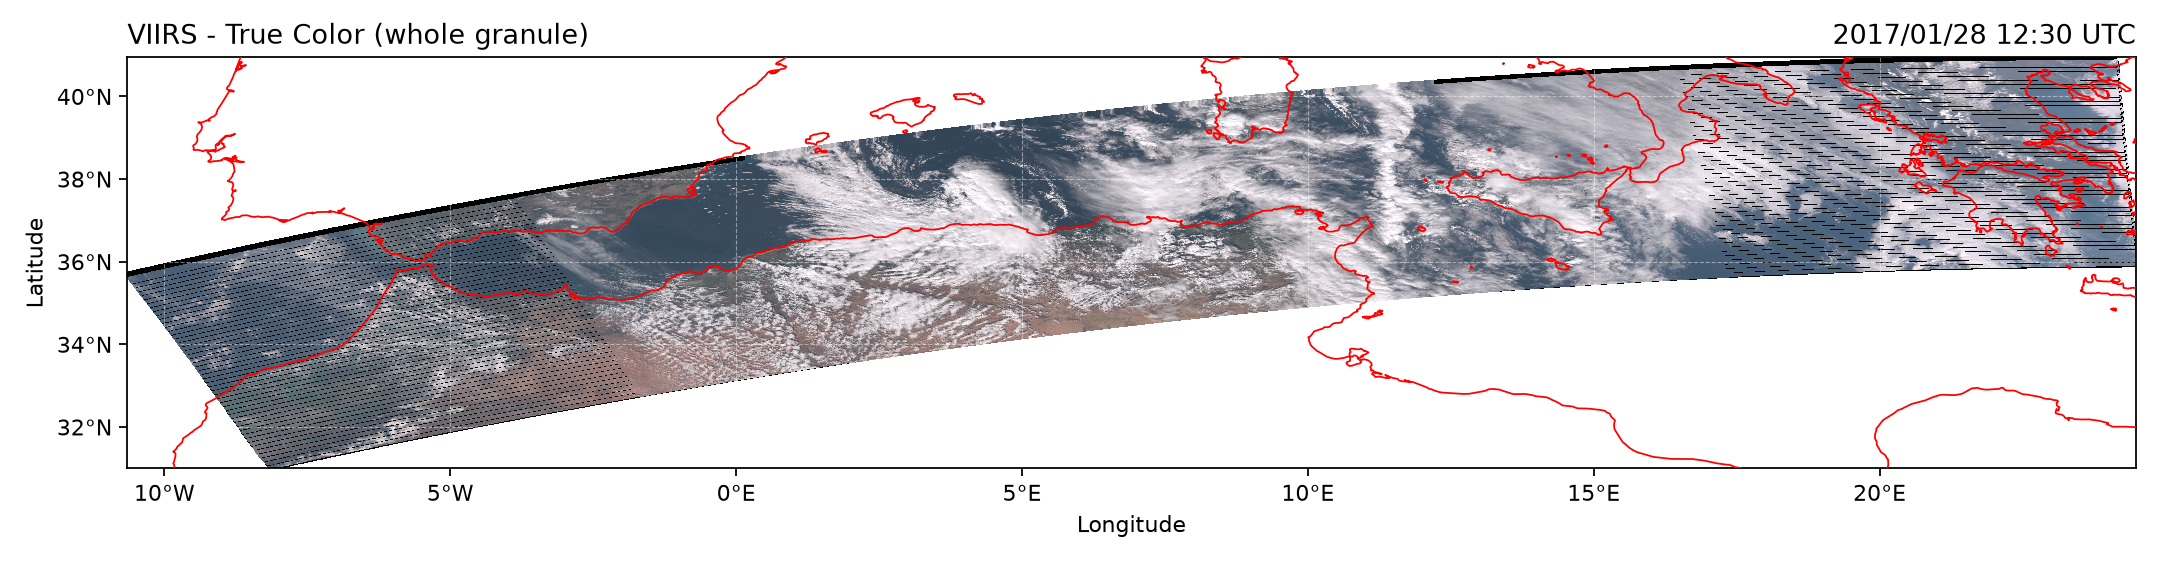

In [5]:
OUT_FULL = Path("../output/viirs_full.png")
OUT_BOX = Path("../output/viirs_box.png")
OUT_FULL.parent.mkdir(parents=True, exist_ok=True)

rgb, lon, lat, when = gt.viirs_true_color(DATA_DIR)
print("granule:", rgb.shape[:2], "at", when)

west, east = float(np.nanmin(lon)), float(np.nanmax(lon))
south, north = float(np.nanmin(lat)), float(np.nanmax(lat))
print(f"extent: {west:.1f} to {east:.1f} lon, {south:.1f} to {north:.1f} lat")

fig, ax = figure_for(west, east, south, north)
ax.pcolormesh(lon, lat, np.zeros(lon.shape), color=rgb.reshape(-1, 3),
              shading="nearest", zorder=0)
decorate(ax, west, east, south, north,
         "VIIRS - True Color (whole granule)", when)
fig.tight_layout(); fig.savefig(OUT_FULL, dpi=DPI); plt.close(fig)
display(Image(filename=str(OUT_FULL)))


## 3. Your box

Write the four numbers yourself. The box must fall inside the granule printed
above: a polar orbiter only sees a strip, so a pass may simply miss your
area.

In [6]:
# LON_MIN, LON_MAX, LAT_MIN, LAT_MAX  -- inside the extent printed above
BOX = (2.0, 8.0, 36.0, 39.0)

print("box:", BOX)


box: (2.0, 8.0, 36.0, 39.0)


## 4. Plot your box

box: (570, 711) pixels


/var/folders/f5/1r66pbnd715gsyd01p3w_gg80000gn/T/ipykernel_90345/1299876199.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(lon, lat, np.zeros(lon.shape), color=rgb.reshape(-1, 3),


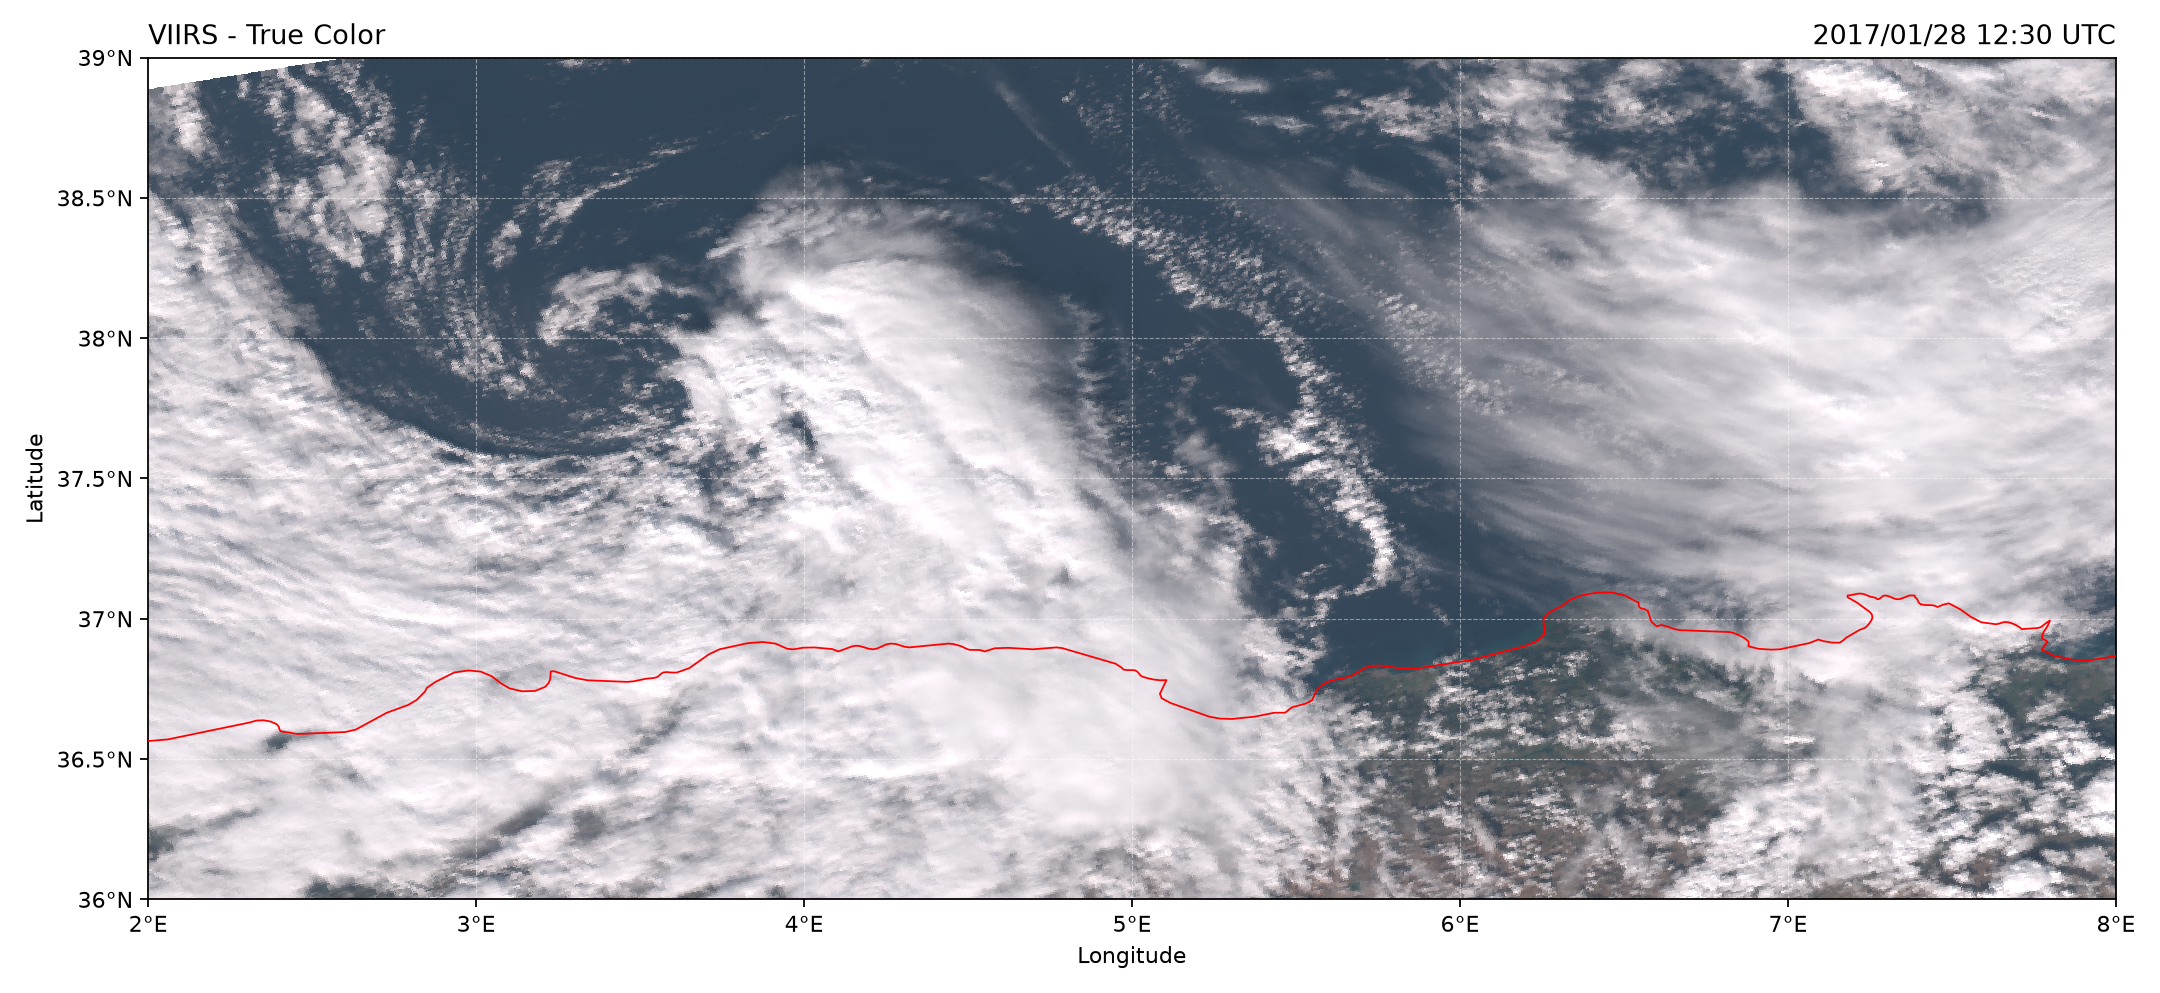

In [7]:
if BOX is None:
    print("No box set -- the whole granule is above.")
else:
    lon_min, lon_max, lat_min, lat_max = BOX
    rgb, lon, lat, when = gt.viirs_true_color(DATA_DIR, lon_min, lon_max,
                                              lat_min, lat_max)
    print("box:", rgb.shape[:2], "pixels")

    fig, ax = figure_for(lon_min, lon_max, lat_min, lat_max)
    ax.pcolormesh(lon, lat, np.zeros(lon.shape), color=rgb.reshape(-1, 3),
                  shading="nearest", zorder=0)
    decorate(ax, lon_min, lon_max, lat_min, lat_max,
             "VIIRS - True Color", when)
    fig.tight_layout(); fig.savefig(OUT_BOX, dpi=DPI); plt.close(fig)
    display(Image(filename=str(OUT_BOX)))


## Notes

* For terrain-corrected geolocation prefer `GMTCO` (M bands) and `GITCO`
  (I bands).
* The I bands sit on a finer grid than the M bands, so they cannot be mixed in
  one call.
* For continuous coverage of one spot use the GOES notebooks instead; VIIRS
  passes over an area only a couple of times a day.